# 03 — The exam: envelope backtesting

A scenario generator is a density forecaster of macro futures, so it can sit the
standard exam: stand at each past date knowing only the past, emit a cone of
futures, get scored against what actually happened — CRPS (distributional error),
coverage (does "80%" mean 80%?), PIT (is the cone honestly shaped?) — split into
calm vs crisis windows, with bootstrap CIs over jump-offs.

In [1]:
import os, sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Find the folder that contains the `multistate` package (works from
# bl225msc/ or from a self-contained thesis_demo/ bundle).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "multistate").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if (ROOT / "data" / "fed").is_dir():
    os.environ.setdefault("THESIS_DATA_DIR", str(ROOT / "data"))
RESULTS = ROOT / "results"
print(f"root: {ROOT}")

def load_csv(path, produced_by):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}\n  produce it with:\n  {produced_by}")
        return None
    return pd.read_csv(path)

def load_pickle(path, produced_by):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}\n  produce it with:\n  {produced_by}")
        return None
    with path.open("rb") as fh:
        return pickle.load(fh)

root: c:\Users\user\OneDrive\Desktop\thesis_clean\bl225msc\thesis_demo


## Live: one exam question

Jump-off 2007Q4 — the generator is refit on data through 2007Q4 only, then must
cover 2008–2010. Band = 5–95% envelope; black = what reality did.

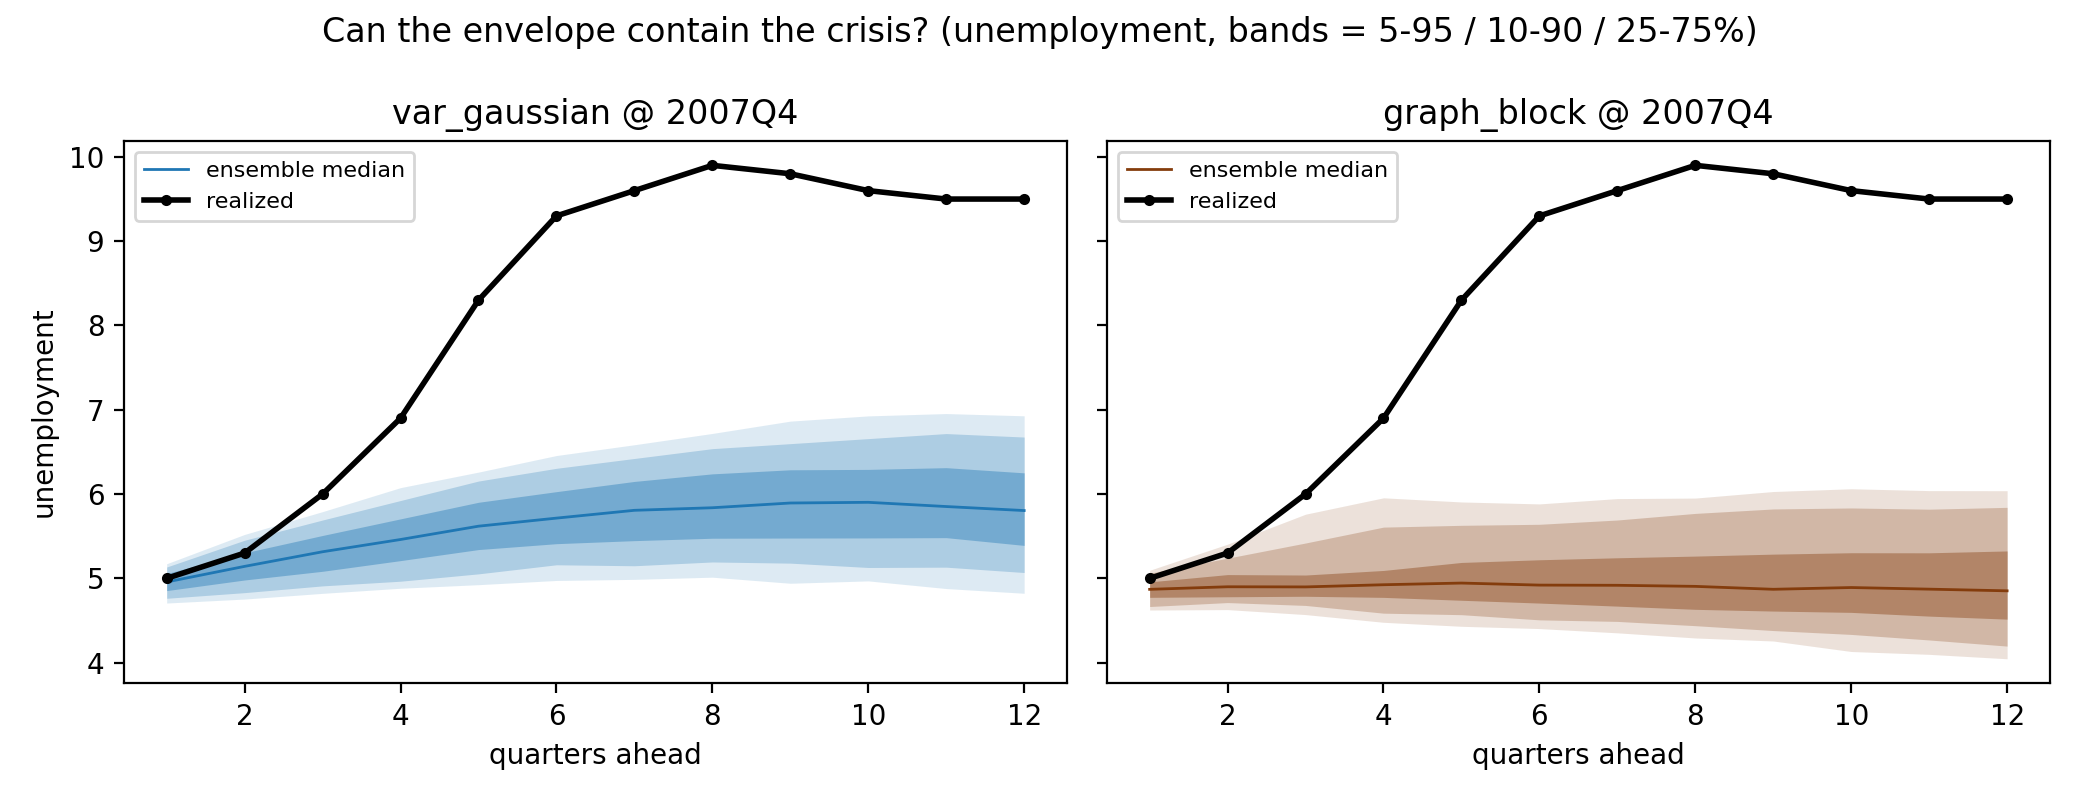

In [2]:
from multistate.scengen.plots import plot_fan
fig_dir = RESULTS / "scengen" / "figures"; fig_dir.mkdir(parents=True, exist_ok=True)
plot_fan(fig_dir, jumpoff_quarter="2007Q4", generators=("var_gaussian", "graph_block"),
         feature="unemployment", n_paths=400)
display(Image(str(fig_dir / "fig_fan_2007Q4_unemployment.png"), width=760))

## Loaded: the full ladder

Every generator, every jump-off. The ablation attributes performance: sparse
structure earns its keep in calm regimes, block-bootstrapped shock persistence
buys crisis realism, and the regime-switching extension does not earn its
estimation cost.

,generator,regime,crps,crps_lo,crps_hi,coverage80_error,coverage95_error,pit_deviation
0,graph_block,calm,1.162,1.020,1.317,0.005,0.017,0.041
1,graph_bootstrap,calm,1.176,1.034,1.348,0.037,0.017,0.049
2,graph_gaussian,calm,1.240,1.110,1.381,0.022,0.010,0.051
3,var_block,calm,1.324,1.170,1.486,0.015,0.023,0.059
4,var_bootstrap,calm,1.342,1.189,1.494,0.011,0.016,0.061
5,var_gaussian,calm,1.385,1.238,1.559,0.044,0.017,0.060
6,delta_bootstrap,calm,1.767,1.533,2.042,0.004,0.052,0.017
7,graph_gaussian,crisis,2.460,2.041,2.899,0.183,0.176,0.005
8,graph_block,crisis,2.499,2.062,2.965,0.185,0.165,0.012
9,graph_bootstrap,crisis,2.503,2.052,2.957,0.233,0.195,0.011


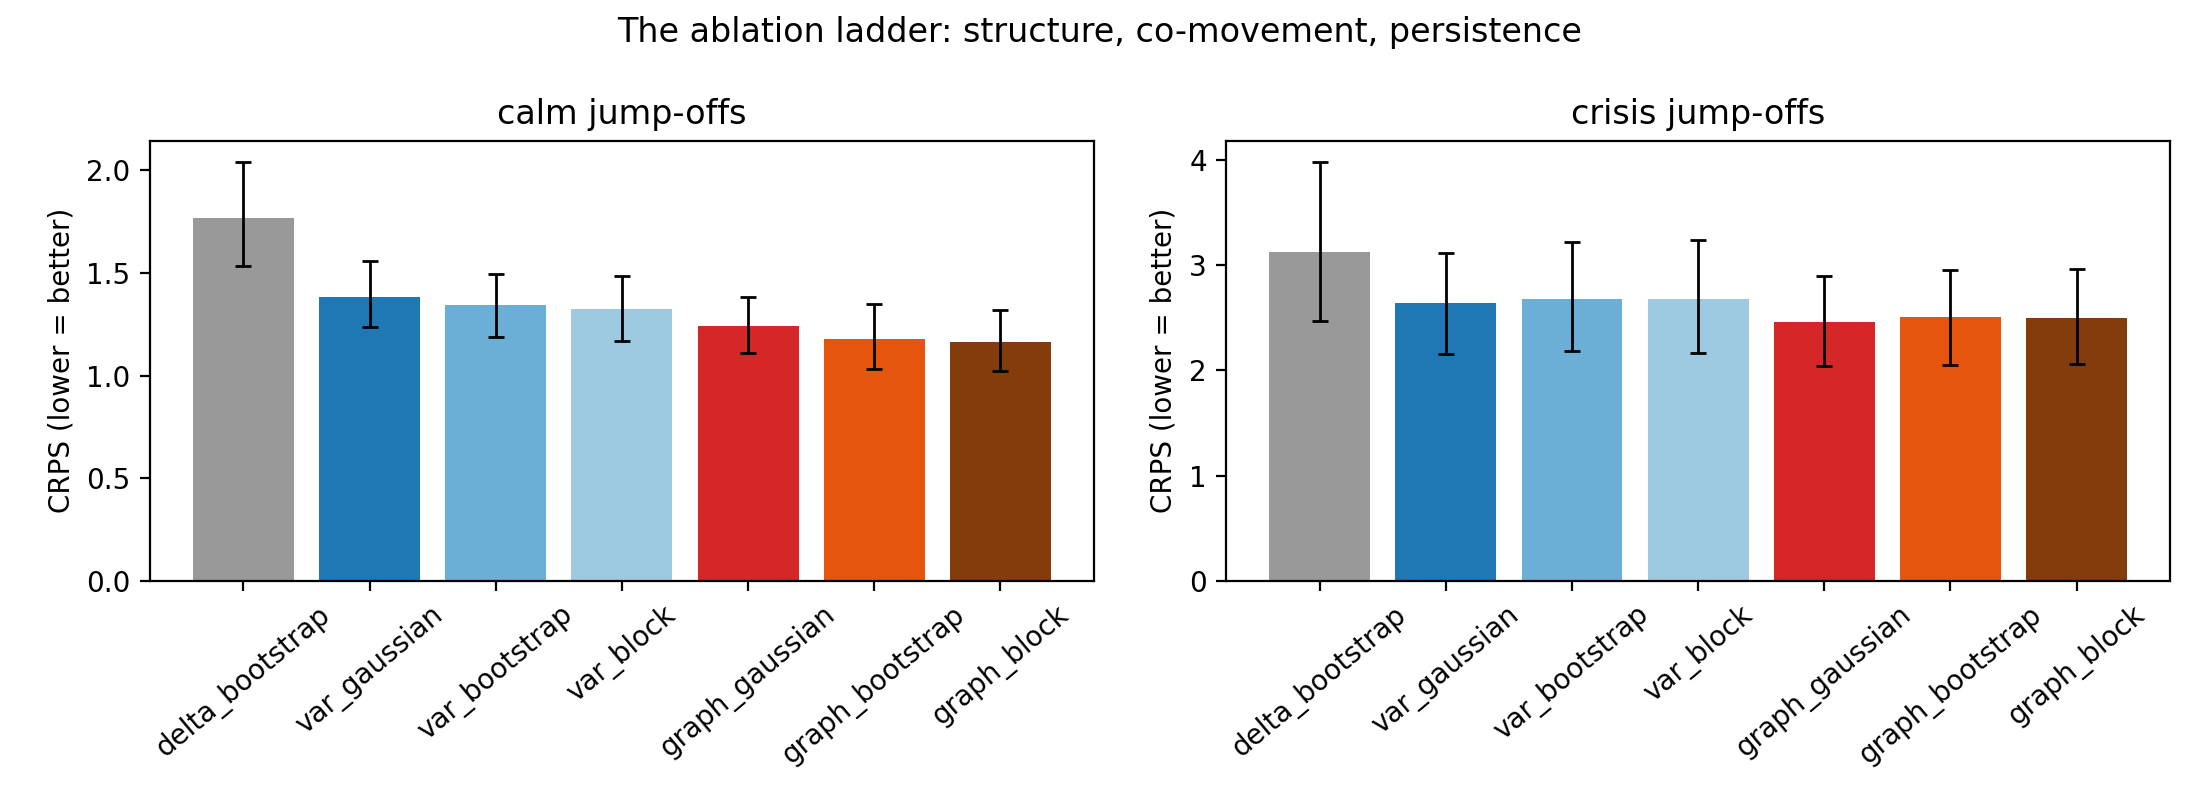

In [3]:
summary = load_csv(RESULTS / "scengen" / "envelope_ladder" / "env_summary.csv",
                   "python -m multistate.scengen.envelope --out results/scengen/envelope_ladder")
if summary is not None:
    cols = [c for c in ["generator","regime","crps","crps_lo","crps_hi",
                        "coverage80_error","coverage95_error","pit_deviation"] if c in summary.columns]
    display(summary[cols].round(3))
    from multistate.scengen.plots import plot_ladder
    plot_ladder(RESULTS / "scengen" / "envelope_ladder" / "env_summary.csv", fig_dir)
    display(Image(str(fig_dir / "fig_crps_ladder.png"), width=760))

## Loaded: the ancestor sits the exam

The Gao-style event-cascade generator (our reimplementation, neutral settings),
graded by the same rules — with the *paired* contrast: both generators sat the
same questions, so we bootstrap per-jump-off differences.

In [4]:
sup = load_csv(RESULTS / "scengen" / "envelope_suppes" / "env_summary.csv",
               "python -m multistate.scengen.envelope --suite suppes --contrast graph_block,suppes --out results/scengen/envelope_suppes")
if sup is not None:
    display(sup[[c for c in ["generator","regime","crps","coverage80_error"] if c in sup.columns]].round(3))
paired = load_csv(RESULTS / "scengen" / "envelope_suppes" / "paired_contrast.csv", "same command as above")
if paired is not None:
    display(paired.round(4))
    print("negative mean diff = graph_block better; calm CI excludes zero (decisive), crisis is directional")

,generator,regime,crps,coverage80_error
0,graph_block,calm,1.193,0.011
1,graph_bootstrap,calm,1.200,0.063
2,graph_gaussian,calm,1.270,0.010
3,var_block,calm,1.380,0.032
4,var_bootstrap,calm,1.403,0.020
5,var_gaussian,calm,1.422,0.057
6,delta_bootstrap,calm,1.874,0.001
7,suppes,calm,2.146,0.407
8,graph_gaussian,crisis,2.502,0.181
9,var_gaussian,crisis,2.526,0.153


,regime,n_jumpoffs,mean_crps_diff,diff_lo,diff_hi,win_share_graph_block
0,calm,8,-0.9535,-1.6671,-0.4945,1.0000
1,crisis,6,-0.3991,-0.9202,0.2620,0.8333


negative mean diff = graph_block better; calm CI excludes zero (decisive), crisis is directional


**Takeaways.** Graph + historical shocks beats the VAR incumbent (~16% CRPS
calm, 5–7% crisis) and decisively dominates the event-cascade ancestor in calm
regimes (100% win share). Residual crisis under-coverage is real, shared by the
whole family, and reported — the exam grades everyone, including us.